In [1]:
import numpy as np 
import matplotlib.pyplot as plt

In [2]:
rosenbrock = lambda v: 100*(v[1] - v[0]**2)**2 + (1 - v[0])**2

In [ ]:
def numerical_gradient(f, theta, h=1e-5):
    theta = np.asarray(theta, dtype=float)
    grad = np.zeros_like(theta)
    for i in range(len(theta)):
        fwd, bwd = theta.copy(), theta.copy()
        fwd[i] += h
        bwd[i] -= h
        grad[i] = (f(fwd) - f(bwd)) / (2*h)
    return grad

In [4]:
def run_armijo(func, x, g, alpha, beta, c):
    while func(x - alpha * g) > func(x) - c * alpha * np.dot(g, g):
        alpha *= beta
    return alpha


def gradient_descent(func, grad, x0, alpha, max_iters, backtrack=True, beta=0.5, c=1e-4, tol=1e-6):
    x = x0.copy().astype(float)
    path = [x.copy()]
    i = 0
    while i < max_iters:
        g = grad(x)
        if np.linalg.norm(g) < tol:
            break
        step = alpha
        if backtrack:
            step = run_armijo(func, x, g, step, beta, c)
        x = x - step * g
        if np.any(np.isnan(x)) or np.any(np.isinf(x)):
            break
        path.append(x.copy())
        i += 1
    return np.array(path)

In [5]:
def plot_contour_with_path(path, func, x, y):
    X, Y = np.meshgrid(x, y)
    Z = func([X, Y])

    plt.contourf(X, Y, np.log1p(Z), levels=30, cmap='viridis')
    plt.colorbar(label='log(1 + f(x,y))')
    plt.plot(path[:, 0], path[:, 1], 'w.-', label='path')
    plt.plot(path[0, 0], path[0, 1], 'go', markersize=10, label='start')
    plt.plot(path[-1, 0], path[-1, 1], 'r*', markersize=15, label='end')
    plt.legend()
    plt.tight_layout()
    plt.show()

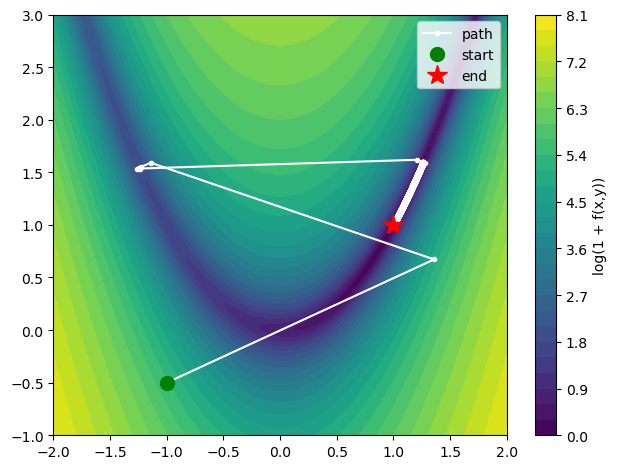

final: [1.00000077 1.00000154] iters: 14057


In [ ]:
path = gradient_descent(
    func = rosenbrock,
    grad = lambda x: numerical_gradient(rosenbrock, x),
    x0 = np.array([-1, -0.5]),
    alpha = 1.0,
    max_iters=1000000,
    backtrack=True)

plot_contour_with_path(path, rosenbrock, np.linspace(-2, 2, 100), np.linspace(-1, 3, 100))

print("final:", path[-1], "iters:", len(path))